# **FLOW 1 — Data Collection & Preprocessing**

---

 ## **1.1. Google Drive Integration**

**Teknik Code:** Google Colab Drive (google.colab.drive.mount())

**Cara Kerja:** Menghubungkan Google Drive dengan lingkungan Colab sehingga dataset, model, maupun hasil pemrosesan dapat dibaca dan disimpan secara langsung.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/GNN_ODE_Traffic')

## **1.2. Import Library dan Dependency**

**Teknik Code:** Import Python Library (osmnx, networkx, pandas, numpy, matplotlib, plotly, dll.)

**Cara Kerja:** Memuat seluruh library yang dibutuhkan untuk proses pengambilan data, analisis graf jalan, visualisasi, dan pemodelan machine learning.

In [ ]:
!pip install osmnx networkx geopandas pandas numpy matplotlib plotly -q

import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from datetime import datetime
import pickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00


## **1.3. Konfigurasi Wilayah Penelitian**

**Teknik Code:** Parameter Configuration

**Cara Kerja:** Menentukan koordinat pusat, radius pencarian, dan parameter awal sebagai dasar pengambilan jaringan jalan.

In [ ]:
# ================== KONFIGURASI ==================
# Koordinat pusat area (Bundaran HI)
center_point = (-6.1944, 106.8229)  # Latitude, Longitude Bundaran HI

# Area yang dicakup (dalam meter)
distance = 2500  # ~2.5 km radius, cukup untuk koridor Sudirman-Thamrin

In [ ]:
G = ox.graph_from_point(center_point, dist=distance,
                        network_type='drive',
                        simplify=True)

# Simpan graph asal
ox.save_graphml(G, "sudirman_thamrin_raw.graphml")
print(f"Graph berhasil di-download! Jumlah nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

Graph berhasil di-download! Jumlah nodes: 2821, edges: 6017


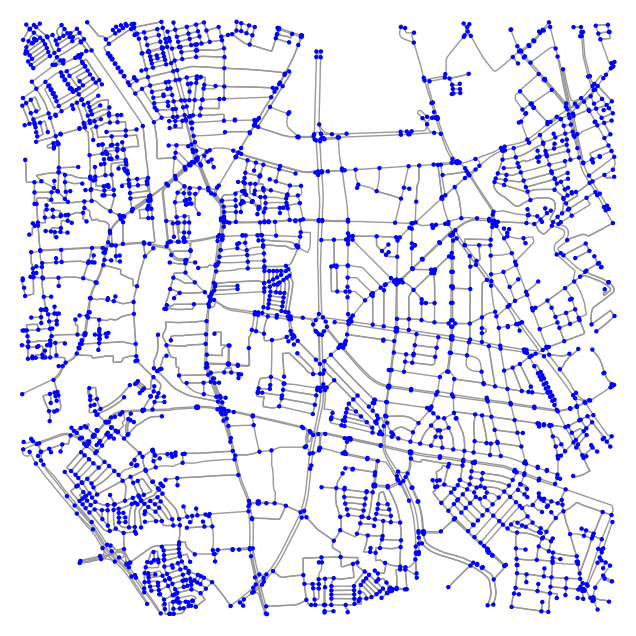

In [ ]:
fig, ax = ox.plot_graph(G, node_size=10, edge_linewidth=1, bgcolor='white', node_color='blue')

## **1.4. Pengambilan Data Road Network**

**Teknik Code:** OSMnx (graph_from_point())

**Cara Kerja:** Mengambil data jaringan jalan dari OpenStreetMap berdasarkan lokasi dan radius yang telah ditentukan.

In [ ]:
import osmnx as ox

print("osmnx version:", ox.__version__)

# Cek dulu apakah graph sudah connected
n_components = nx.number_strongly_connected_components(G)
print(f"Jumlah strongly connected components: {n_components}")

if n_components > 1:
    # Version-safe: coba API baru, fallback ke API lama
    try:
        G = ox.truncate.largest_component(G, strongly=True)
    except AttributeError:
        G = ox.utils_graph.get_largest_component(G, strongly=True)
    print(f"Setelah filter -> nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")
else:
    print("Graph sudah 1 component, skip filtering.")

# Tambah speed limit & kapasitas sederhana (untuk modeling nanti)
for u, v, k, data in G.edges(keys=True, data=True):
    if 'highway' in data:
        hwy = data['highway']
        hwy = hwy[0] if isinstance(hwy, list) else hwy  # highway kadang list
        if hwy in ['motorway', 'trunk']:
            data['speed_kph'] = 80
        elif hwy in ['primary', 'secondary']:
            data['speed_kph'] = 60
        else:
            data['speed_kph'] = 40
    else:
        data['speed_kph'] = 40

    # Sekalian tambah kapasitas simple berdasarkan jumlah lane
    lanes = data.get('lanes', 1)
    if isinstance(lanes, list):
        lanes = lanes[0]
    try:
        lanes = int(lanes)
    except (ValueError, TypeError):
        lanes = 1
    data['capacity'] = lanes * 1800  # asumsi kapasitas 1800 kendaraan/jam per lane (kasar)

with open('sudirman_thamrin_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print("Graph sudah disimpan!")

osmnx version: 2.1.0
Jumlah strongly connected components: 105
Setelah filter -> nodes: 2669, edges: 5783
Graph sudah disimpan!


## **1.5. Konversi Graph menjadi DataFrame**

**Teknik Code:** Graph Processing menggunakan OSMnx & Pandas

**Cara Kerja:** Mengubah graph menjadi tabel node dan edge agar lebih mudah dianalisis dan diproses.

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Setup time range: 1 minggu, resolusi 5 menit
start = pd.Timestamp('2026-01-06 00:00')  # Senin
end = start + pd.Timedelta(days=7)
timestamps = pd.date_range(start, end, freq='5min')[:-1]

def congestion_factor(ts):
    """
    Return faktor pengali speed (0.15 - 1.0) berdasarkan jam & hari.

    DIKALIBRASI berdasarkan TomTom Traffic Index Jakarta (data 2025, rilis Jan 2026)
    dan liputan media terkait, karena data sensor riil per-ruas-jalan tidak tersedia publik:
      - Congestion Level (CL) jam macet pagi (07.00-09.00 WIB) ~= 43%
        -> speed_mult = 1/(1+CL) ~= 0.70   [sumber: traveloka.com, kutip TomTom]
      - CL jam macet sore (17.00-18.00 WIB, window puncak 16.30-19.00) ~= 62-67%
        -> speed_mult ~= 0.60              [sumber: traveloka.com; viva.co.id Okt 2025]
      - CL rata-rata tahunan 2025 = 59.8%, kecepatan rata-rata jam sibuk = 22.8 km/h
        [sumber: tomtom.com/traffic-index/city/jakarta, TomTom Traffic Index 2025]
    Catatan: CL tahunan 59.8% adalah rata-rata 24 jam di seluruh metro (bukan spesifik
    jam puncak/koridor arteri), jadi dipakai sebagai sanity-check arah besar saja,
    bukan target eksak untuk base non-puncak.
    """
    hour = ts.hour + ts.minute / 60
    is_weekend = ts.dayofweek >= 5

    if is_weekend:
        base = 0.85  # weekend relatif lancar (belum ada angka kalibrasi spesifik weekend)
        # sedikit dip siang hari (mall, dll)
        dip = 0.15 * np.exp(-((hour - 14) ** 2) / 8)
    else:
        base = 0.9
        # Pagi: puncak jam 08.00, window ~07.00-09.00, target factor puncak ~0.70 (CL ~43%)
        dip_pagi = 0.20 * np.exp(-((hour - 8.0) ** 2) / 1.2)
        # Sore: puncak jam 17.45 (tengah window 16.30-19.00), target factor puncak ~0.60 (CL ~62-67%)
        dip_sore = 0.30 * np.exp(-((hour - 17.75) ** 2) / 2.2)
        dip = dip_pagi + dip_sore

    factor = base - dip
    return np.clip(factor, 0.15, 1.0)

# Precompute faktor waktu (sama untuk semua edge sebagai baseline pattern)
time_factors = np.array([congestion_factor(ts) for ts in timestamps])

edges = list(G.edges(keys=True, data=True))
n_edges = len(edges)
n_time = len(timestamps)

# Spatial correlation sederhana: edge yang share node akan punya noise yang mirip
# Generate node-level noise dulu, lalu edge speed = rata2 noise dari node u & v
node_ids = list(G.nodes())
node_idx = {n: i for i, n in enumerate(node_ids)}

# Random walk noise per node biar smooth antar waktu (bukan white noise murni)
node_noise = np.zeros((len(node_ids), n_time))
for i in range(len(node_ids)):
    walk = np.cumsum(np.random.normal(0, 0.02, n_time))
    walk = walk - walk.mean()
    node_noise[i] = np.clip(walk, -0.25, 0.25)

records = []
for (u, v, k, data) in edges:
    free_flow = data['speed_kph']
    ui, vi = node_idx[u], node_idx[v]
    edge_noise = (node_noise[ui] + node_noise[vi]) / 2
    factor = np.clip(time_factors + edge_noise, 0.1, 1.0)
    speed = free_flow * factor
    speed += np.random.normal(0, 1.0, n_time)  # sensor noise kecil
    speed = np.clip(speed, 3, free_flow)  # gak boleh negatif atau lebih dari free flow

    for t_idx, ts in enumerate(timestamps):
        records.append((u, v, k, ts, speed[t_idx]))

df_speed = pd.DataFrame(records, columns=['u', 'v', 'k', 'timestamp', 'speed_kph'])
df_speed.to_parquet('synthetic_traffic_speed.parquet', index=False)
print(f"Generated {len(df_speed):,} rows untuk {n_edges} edges x {n_time} timestamps")
df_speed.head()

Generated 11,658,528 rows untuk 5783 edges x 2016 timestamps


,u,v,k,timestamp,speed_kph
0,29938969,4488259599,0,2026-01-06 00:00:00,39.899763
1,29938969,4488259599,0,2026-01-06 00:05:00,39.164930
2,29938969,4488259599,0,2026-01-06 00:10:00,39.562785
3,29938969,4488259599,0,2026-01-06 00:15:00,38.711528
4,29938969,4488259599,0,2026-01-06 00:20:00,40.094011


## **1.6. Visualisasi Jaringan Jalan**

**Teknik Code:** OSMnx Visualization (plot_graph())

**Cara Kerja:** Menampilkan struktur jaringan jalan untuk memastikan data berhasil diperoleh dengan benar.

/tmp/ipykernel_1268/4188335614.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')


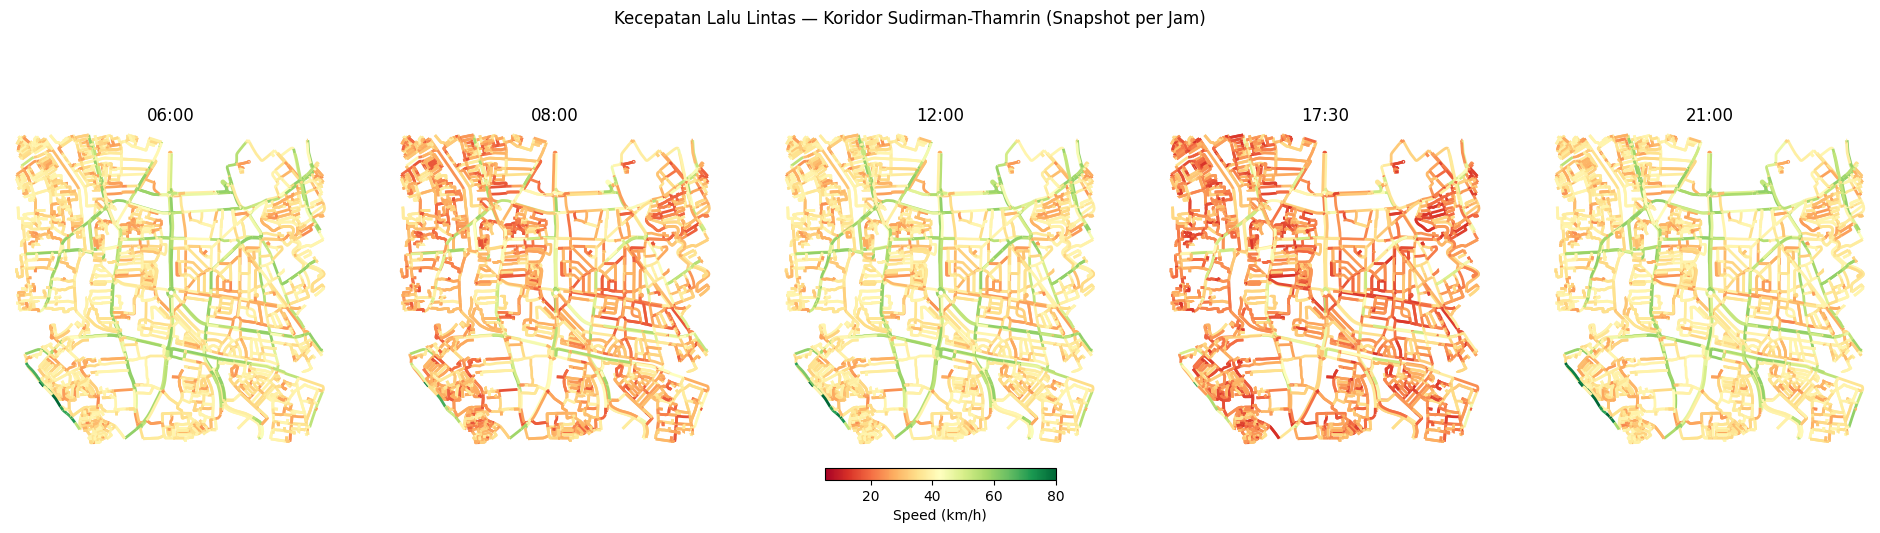

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# Pilih beberapa jam kunci aja (representative snapshot)
snapshot_times = pd.to_datetime([
    '2026-01-06 06:00',  # pagi lengang
    '2026-01-06 08:00',  # macet pagi
    '2026-01-06 12:00',  # siang
    '2026-01-06 17:30',  # macet sore
    '2026-01-06 21:00',  # malam
])

# Colormap: merah = lambat, hijau = cepat
norm = mcolors.Normalize(vmin=5, vmax=80)
cmap = cm.get_cmap('RdYlGn')

fig, axes = plt.subplots(1, len(snapshot_times), figsize=(24, 5))

for ax, ts in zip(axes, snapshot_times):
    df_t = df_speed[df_speed['timestamp'] == ts].set_index(['u', 'v', 'k'])

    edge_colors = []
    for u, v, k, data in G.edges(keys=True, data=True):
        try:
            speed = df_t.loc[(u, v, k), 'speed_kph']
        except KeyError:
            speed = data['speed_kph']
        edge_colors.append(cmap(norm(speed)))

    ox.plot_graph(
        G, ax=ax, node_size=0,
        edge_color=edge_colors, edge_linewidth=2,
        bgcolor='white', show=False, close=False
    )
    ax.set_title(ts.strftime('%H:%M'), fontsize=12)

# Colorbar bersama
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.05, label='Speed (km/h)')

plt.suptitle('Kecepatan Lalu Lintas — Koridor Sudirman-Thamrin (Snapshot per Jam)', y=1.05)
plt.savefig('traffic_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # penting: bebasin memory